### Imports

In [1]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import utils
import matplotlib.pyplot as plt
from datetime import datetime

### Download the MNIST-Dataset

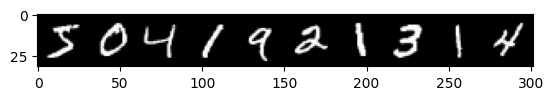

In [11]:
training_data = datasets.MNIST(
    root="./data",
    train=True,
    transform=ToTensor(),
    download=True
)

validation_data = datasets.MNIST(
    root="./data",
    train=False,
    transform=ToTensor(),
    download=True
)

# Get the first 10 images in the training dataset
images = [image for image, _ in [training_data[i] for i in range(10)]]
# Create a grid of images
grid = utils.make_grid(images, nrow=10)
grid = grid.permute(1, 2, 0)    # Change the order of dimensions (CxHxW) to (HxWxC)
plt.imshow(grid)
plt.show()


### Create the DataLoaders

In [12]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    training_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4
)

valid_dataloader = DataLoader(
    validation_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

for images, labels in train_dataloader:
    print(f"Shape of image [N, C, H, W]: {images.shape}; dtype = {images.dtype}")
    print(f"Shape of label: {labels.shape}; dtype = {labels.dtype}")
    break

Shape of image [N, C, H, W]: torch.Size([64, 1, 28, 28]); dtype = torch.float32
Shape of label: torch.Size([64]); dtype = torch.int64


### Create the Model

In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Flatten()                     
        self.hidden_layer1 = nn.Sequential(                
            nn.Linear(in_features=28*28, out_features=512),
            nn.ReLU()
        )
        self.hidden_layer2 = nn.Sequential(
            nn.Linear(in_features=512, out_features=512),
            nn.ReLU()
        )
        self.output_layer = nn.Linear(in_features=512, out_features=10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer1(x)
        x = self.hidden_layer2(x)
        logits = self.output_layer(x)
        return logits
    
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (input_layer): Flatten(start_dim=1, end_dim=-1)
  (hidden_layer1): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
  )
  (hidden_layer2): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
  )
  (output_layer): Linear(in_features=512, out_features=10, bias=True)
)


In [5]:
def train(dataloader, model, loss_function, optimizer, device):
    size = len(dataloader.dataset)
    model.train()

    epoch_loss = 0
    epoch_accuracy = 0
    for batch, (images, labels) in enumerate(dataloader):
        images, labels = images.to(device), labels.to(device)

        ## Forward pass
        # Get prediction
        prediction = model(images)
        # Calculate the loss
        loss = loss_function(prediction, labels)

        ## Backpropagation
        # Calculate the gradient
        loss.backward()
        # Updata parameters
        optimizer.step()
        # Zero the gradient
        optimizer.zero_grad()

        # Calculate the accuracy
        accuracy = (prediction.argmax(dim=1) == labels).float().mean()
        
        epoch_loss += loss.item()
        epoch_accuracy += accuracy.item()

    num_batches = len(dataloader)
    avg_loss = epoch_loss / num_batches
    avg_accuracy = epoch_accuracy / num_batches
    print(f"Train average:      loss: {avg_loss:>7f}  accuracy: {100*avg_accuracy:>0.1f}%")
    return epoch_loss / num_batches, epoch_accuracy / num_batches

def validation(dataloader, model, loss_function, device):
    size = len(dataloader.dataset)
    model.eval()

    epoch_loss = 0
    epoch_accuracy = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            ## Forward pass
            # Get prediction
            prediction = model(images)
            # Calculate the loss
            loss = loss_function(prediction, labels)

            ## During validation parameters do not get updaten (No backward pass)

            # Calculate the accuracy
            accuracy = (prediction.argmax(dim=1) == labels).float().mean()
            
            epoch_loss += loss.item()
            epoch_accuracy += accuracy.item()

    num_batches = len(dataloader)
    avg_loss = epoch_loss / num_batches
    avg_accuracy = epoch_accuracy / num_batches
    print(f"Validation average: loss: {avg_loss:>7f}  accuracy: {100*avg_accuracy:>0.1f}%\n")
    return epoch_loss / num_batches, epoch_accuracy / num_batches            

In [7]:
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")

epochs = 10
learning_rate = 1e-3

loss_function = nn.CrossEntropyLoss()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
model = NeuralNetwork().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

best_val_loss = 1_000_000
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss, train_accuracy = train(train_dataloader, model, loss_function, optimizer, device)
    val_loss, val_accuracy = validation(valid_dataloader, model, loss_function, device)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model_path = "checkpoints/model_{}_e_{}".format(timestamp, t)
        torch.save(model.state_dict(), model_path)

Device: cpu
Epoch 1
-------------------------------
Train average:      loss: 0.226289  accuracy: 93.2%
Validation average: loss: 0.125575  accuracy: 95.9%

Epoch 2
-------------------------------
Train average:      loss: 0.086748  accuracy: 97.3%
Validation average: loss: 0.092684  accuracy: 97.1%

Epoch 3
-------------------------------
Train average:      loss: 0.056947  accuracy: 98.2%
Validation average: loss: 0.080249  accuracy: 97.6%

Epoch 4
-------------------------------
Train average:      loss: 0.041734  accuracy: 98.7%
Validation average: loss: 0.072727  accuracy: 97.9%

Epoch 5
-------------------------------
Train average:      loss: 0.032597  accuracy: 98.9%
Validation average: loss: 0.075145  accuracy: 97.9%

Epoch 6
-------------------------------
Train average:      loss: 0.025431  accuracy: 99.1%
Validation average: loss: 0.087412  accuracy: 97.8%

Epoch 7
-------------------------------
Train average:      loss: 0.022214  accuracy: 99.3%
Validation average: loss: 

### Inference

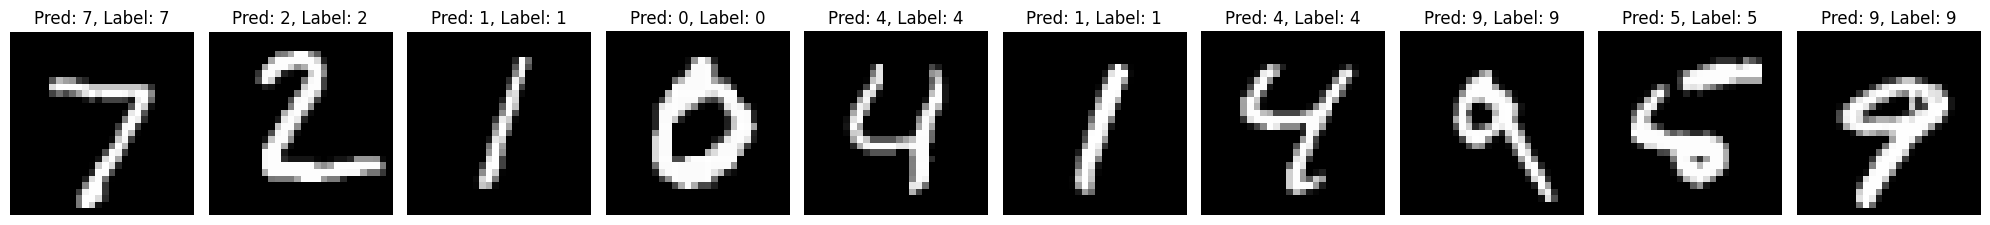

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("checkpoints/model_2026_04_22_19_09_23_e_3", weights_only=True))
model.eval()

fig, axes = plt.subplots(1, 10, figsize=(20, 3))

with torch.no_grad():
    for i in range(10):
        image, label = validation_data[i]
        
        image = image.to(device)
        prediction = model(image)
        predicted = prediction[0].argmax(0).item()

        image = image.permute(1, 2, 0) # (CxHxW) -> (HxWxC)
        axes[i].imshow(image, cmap="gray")
        axes[i].set_title(f"Pred: {predicted}, Label: {label}")
        axes[i].axis("off")

plt.tight_layout()
plt.show()